Inverse problems and machine learning
======================================

In [142]:
#pip install deepinv

In [16]:
import deepinv as dinv
import torch
import numpy as np

device = dinv.utils.get_device()

Selected CPU device


## Physics
In DeepInverse, `x` are images:


In [2]:
x = dinv.utils.load_example("butterfly.png", device=device)
print(x.shape)

torch.Size([1, 3, 256, 256])


`Imaging forward operators <physics_intro>` are called `physics` and simulate
measurements `y` from `x`.


In [3]:
physics = dinv.physics.Inpainting(x.shape[1:], mask=0.3, device=device)

y = physics(x)

DeepInverse implements
`many different types of physics <physics>` across various imaging modalities.
Physics also possess noise models such as Gaussian or Poisson noise.



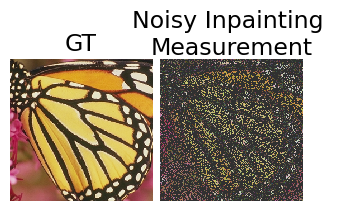

In [5]:
physics.noise_model = dinv.physics.GaussianNoise(sigma=0.1)

y = physics(x)

dinv.utils.plot({"GT": x, "Noisy Inpainting \nMeasurement": y})

You can easily use your own params by passing these into the `physics`,
or you can use a `generator` to `generate random params <physics_generators>`:



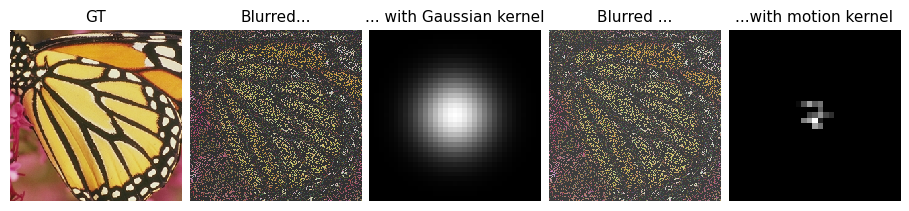

In [10]:
# Blur with Gaussian filter parameter
filter = dinv.physics.functional.gaussian_blur(sigma=(5, 5))

# Blur kernel random generator
physics_generator = dinv.physics.generator.MotionBlurGenerator(
    psf_size=(31, 31), num_channels=3, device=device
)

# Generate a dict of random params {"filter": ...}
params = physics_generator.step()

# Update physics during forward call
y2 = physics(x, **params)

dinv.utils.plot(
    {
        "GT": x,
        "Blurred...": y,
        "... with Gaussian kernel": filter,
        "Blurred ...": y2,
        "...with motion kernel": params["filter"],
    },
    fontsize=11
)

Physics are powerful objects and `have many methods <physics_intro>`, for example a
pseudo-inverse:


In [13]:
# You can also update params like so
physics.update(filter=filter.to(device))

x_pinv = physics.A_dagger(y)

in the field of inverse problems, the pseudo-inverse can give good results
if the problem is noiseless, but it completely fails in the presence of noise - this is why we need reconstructors!

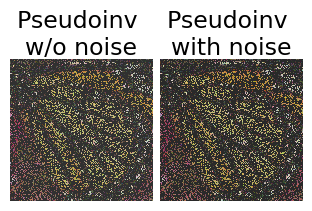

similarity check  False


In [20]:
physics.noise_model = dinv.physics.GaussianNoise(sigma=0.1)

y = physics(x)

x_pinv_noise = physics.A_dagger(y)

dinv.utils.plot(
    {"Pseudoinv \nw/o noise": x_pinv, "Pseudoinv \nwith noise": x_pinv_noise}
)

print('similarity check ',np.allclose(x_pinv,x_pinv_noise))

### In DeepInverse, a `model` is a reconstruction algorithm that **reconstructs** images from `y` and knowledge of `physics`.


In [21]:
model = dinv.models.RAM(pretrained=True, device=device)

x_hat = model(y, physics)

Downloading: "https://huggingface.co/mterris/ram/resolve/main/ram.pth.tar" to /HOME1/users/personal/prol/.cache/torch/hub/checkpoints/ram.pth.tar


 93%|█████████▎| 126M/136M [00:08<00:00, 16.5MB/s] 


KeyboardInterrupt: 

Plot the image `x`, the measurement `y` and the reconstructed image
`x_hat` and compute `metrics <metric>`:


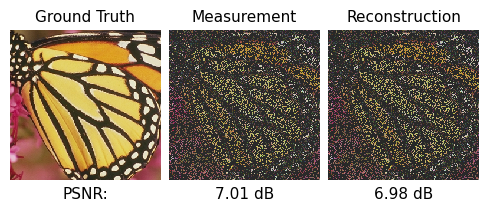

In [32]:
metric = dinv.metric.PSNR()

psnr_y = metric(y, x).item()
psnr_x_hat = metric(x_hat, x).item()

dinv.utils.plot(
    {
        "Ground Truth": x,
        "Measurement": y,
        "Reconstruction": x_hat,
    },
    fontsize=11,
    subtitles=["PSNR:", f"{psnr_y:.2f} dB", f"{psnr_x_hat:.2f} dB"],
)

Some models are only denoisers <denoisers> that denoise images from y and sigma, which can be used to build many model-based reconstruction algorithms <iterative>.

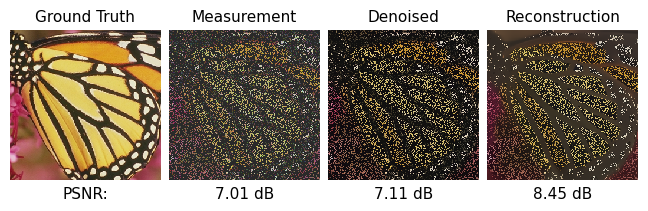

In [34]:
denoiser = dinv.models.DRUNet(device=device)

x_denoised = denoiser(y, sigma=0.1)

model = dinv.optim.DPIR(sigma=0.1, denoiser=denoiser, device=device)

x_hat = model(y, physics)

dinv.utils.plot(
    {
        "Ground Truth": x,
        "Measurement": y,
        "Denoised": x_denoised,
        "Reconstruction": x_hat,
    },
    fontsize=11,
    subtitles=[
        "PSNR:",
        f"{dinv.metric.PSNR()(y, x).item():.2f} dB",
        f"{dinv.metric.PSNR()(x_denoised, x).item():.2f} dB",
        f"{dinv.metric.PSNR()(x_hat, x).item():.2f} dB",
    ],
)

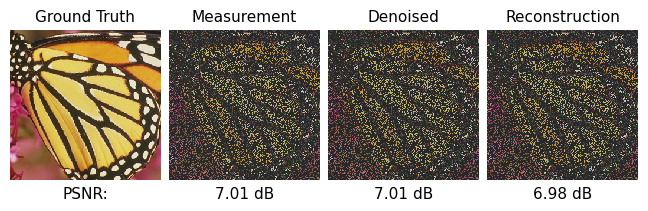

In [30]:
denoiser = dinv.models.DnCNN(device=device)

x_denoised = denoiser(y, sigma=0.1)

model = dinv.optim.DPIR(sigma=0.1, denoiser=denoiser, device=device)

x_hat = model(y, physics)

dinv.utils.plot(
    {
        "Ground Truth": x,
        "Measurement": y,
        "Denoised": x_denoised,
        "Reconstruction": x_hat,
    },
    fontsize=11,
    subtitles=[
        "PSNR:",
        f"{dinv.metric.PSNR()(y, x).item():.2f} dB",
        f"{dinv.metric.PSNR()(x_denoised, x).item():.2f} dB",
        f"{dinv.metric.PSNR()(x_hat, x).item():.2f} dB",
    ],
)

Let us define a basic training routine for the DnCNN

In [136]:
import random

a=random.random()
print(a)

0.8637887922919791


torch.Size([3, 128, 128]) torch.Size([1, 3, 128, 128])


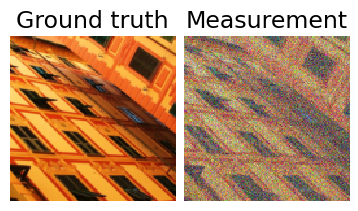

training model...


In [139]:
from torchvision.transforms import Compose, ToTensor, Resize, CenterCrop, Grayscale
from torch.utils.data import DataLoader

import random

dataset=dinv.datasets.Urban100HR(transform=Compose([ToTensor(), Resize(512), CenterCrop(128)]))

#dataset=dinv.datasets.CBSD68(transform=Compose([ToTensor(), Resize(256), CenterCrop(128)]))


train_dataset, test_dataset = torch.utils.data.random_split(
    torch.utils.data.Subset(dataset, range(50)), (0.8, 0.2)
)

#CBSD68


#train_dataset = dinv.datasets.DIV2K(mode='train', download=True)#, patch_size=patch_size)
#test_dataset = dinv.datasets.DIV2K(mode='test', download=True)#, patch_size=patch_size)



# We use a denoising physics model with Gaussian noise
physics =dinv.physics.Denoising(noise_model=dinv.physics.GaussianNoise(sigma=0.2))



# Initialize DnCNN model
model = dinv.models.DnCNN(in_channels=3, out_channels=3,pretrained=None).to(device)


# Loss function (MSE is standard for denoising)
loss_fn = torch.nn.MSELoss()

# Peak Signal-to-noise Ratio (dB)
psnr_metric = dinv.metric.PSNR()

optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

n_epochs = 10


#batch_size = 16

train_loader = DataLoader(train_dataset, shuffle=True)
test_loader = DataLoader(test_dataset, shuffle=False)

x = next(iter(test_loader))

print(x[0].shape,physics(x).shape)


dinv.utils.plot({"Ground truth": x[0], "Measurement": physics(x)})

def train_model(model, train_loader, test_loader, physics, loss_fn, optimizer, n_epochs, psnr_metric): 
    for epoch in range(n_epochs):
        model.train()
        train_loss = 0.0
        for x in train_loader:
            x = x.to(device)
            noise = random.uniform(0,.4)
            physics =dinv.physics.Denoising(noise_model=dinv.physics.GaussianNoise(sigma=noise))

            # Forward pass: add noise and denoise
            y = physics(x)
            x_hat = model(y)
            
            # Compute loss
            loss = loss_fn(x_hat, x)
            
            # Backward pass and optimize
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
            
            train_loss += loss.item()
        
        # Print training loss
        avg_train_loss = train_loss / len(train_loader)
        print(f"Epoch {epoch+1}/{n_epochs}, Train Loss: {avg_train_loss:.4f}")
        
        # Validation
        model.eval()
        val_loss = 0.0
        val_psnr = 0.0
        with torch.no_grad():
            for x in test_loader:
                x = x.to(device)
                y = physics(x)
                x_hat = model(y)
                val_loss += loss_fn(x_hat, x).item()
                val_psnr += psnr_metric(x_hat, x).item()
        avg_val_loss = val_loss / len(test_loader)
        avg_val_psnr = val_psnr / len(test_loader)
        print(f"Epoch {epoch+1}/{n_epochs}, Val Loss: {avg_val_loss:.4f}, Val PSNR: {avg_val_psnr:.2f} dB")

print('training model...')
#train_model(model, train_loader, test_loader, physics, loss_fn, optimizer, n_epochs, psnr_metric)

In [140]:
print('training model...')
train_model(model, train_loader, test_loader, physics, loss_fn, optimizer, n_epochs, psnr_metric)

training model...
Epoch 1/10, Train Loss: 0.3604
Epoch 1/10, Val Loss: 0.3864, Val PSNR: 4.13 dB
Epoch 2/10, Train Loss: 0.2670
Epoch 2/10, Val Loss: 0.5474, Val PSNR: 2.62 dB
Epoch 3/10, Train Loss: 0.2654
Epoch 3/10, Val Loss: 0.0127, Val PSNR: 18.99 dB
Epoch 4/10, Train Loss: 0.3276
Epoch 4/10, Val Loss: 0.0863, Val PSNR: 10.64 dB
Epoch 5/10, Train Loss: 0.2800
Epoch 5/10, Val Loss: 0.2913, Val PSNR: 5.36 dB
Epoch 6/10, Train Loss: 0.2043
Epoch 6/10, Val Loss: 0.0668, Val PSNR: 11.75 dB
Epoch 7/10, Train Loss: 0.2392
Epoch 7/10, Val Loss: 0.8207, Val PSNR: 0.86 dB
Epoch 8/10, Train Loss: 0.2434
Epoch 8/10, Val Loss: 0.5046, Val PSNR: 2.97 dB
Epoch 9/10, Train Loss: 0.2517
Epoch 9/10, Val Loss: 0.1120, Val PSNR: 9.51 dB
Epoch 10/10, Train Loss: 0.2255
Epoch 10/10, Val Loss: 0.1739, Val PSNR: 7.60 dB


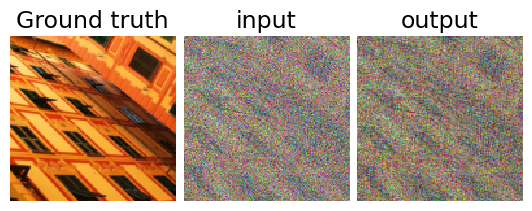

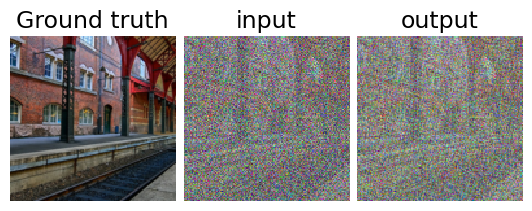

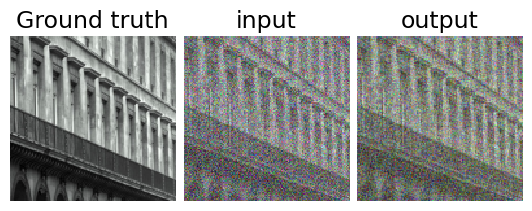

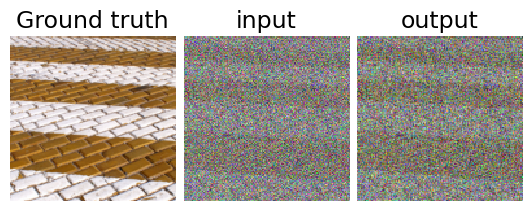

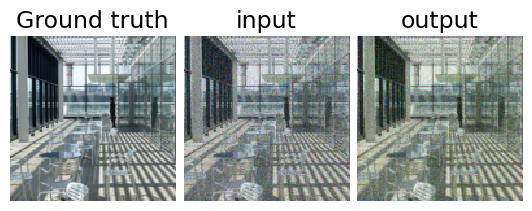

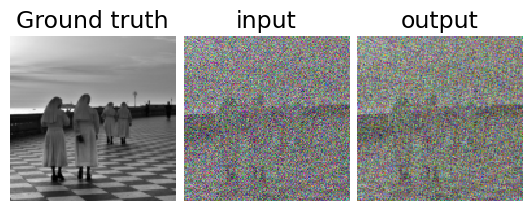

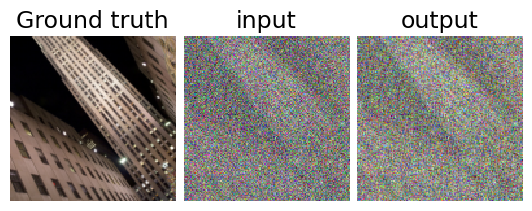

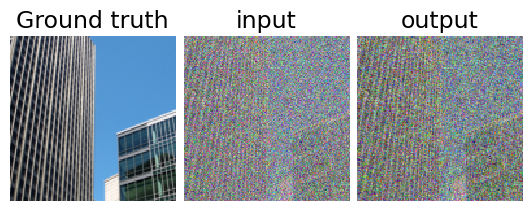

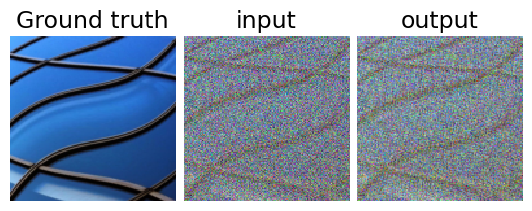

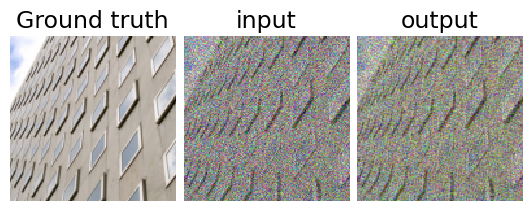

In [141]:
for x in test_loader:
    x = x.to(device)
    physics =dinv.physics.Denoising(noise_model=dinv.physics.GaussianNoise(sigma=random.uniform(0,0.4)))
    y = physics(x)
    x_hat = model(y)
    dinv.utils.plot({"Ground truth": x[0],'input': y, "output": x_hat})
